# Motorneuron dataset of larva zebrafish 

The following analysis on this data is meant to demonstrate the analysis pipeline using the developed toolbox.

This data was already discussed in the paper by [Fallani et al (2014)](https://pubmed.ncbi.nlm.nih.gov/25122836/)



The data was acquired using SCAPE at 4 Hz. 

 

#### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.d_CSL import GcStar
from src.d_CSL import Visualize_on_topography
from src.dataload import load_data
from src.dataPreProcessing import replace_nan


# if variables are changed on the fly 
from reloading import reloading

In [2]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

### Load data

The data are provided in `.npy` file types. However, the `load_data()` function can load `.txt` as well as `pickle` files.

In [3]:
background = load_data(r'./data/motorneurons/fish3_trace2_background.npy')
centers = load_data(r'./data/motorneurons/fish3_trace2_centroids.npy')
X = load_data(r'./data/motorneurons/fish3_trace2_dff.npy')

### Preprocess data 

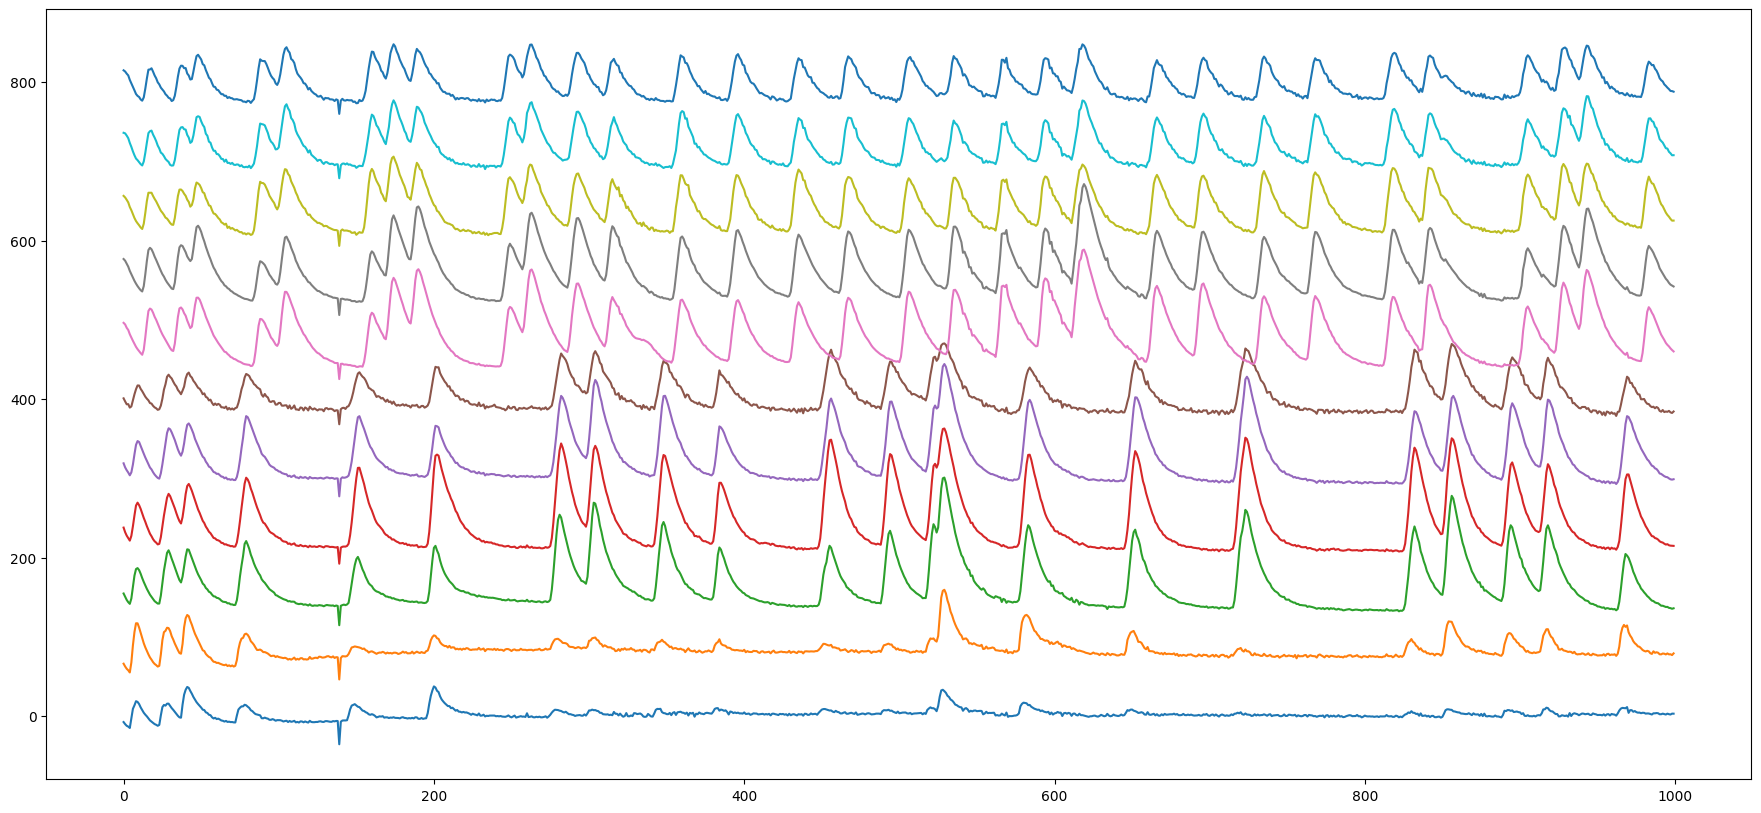

In [4]:
plt.figure(figsize=(22,10))
for i in range(X.shape[0]):
    plt.plot(X[i]+ i*80)

Here we interpolate the and replace the artefact value at frame 139

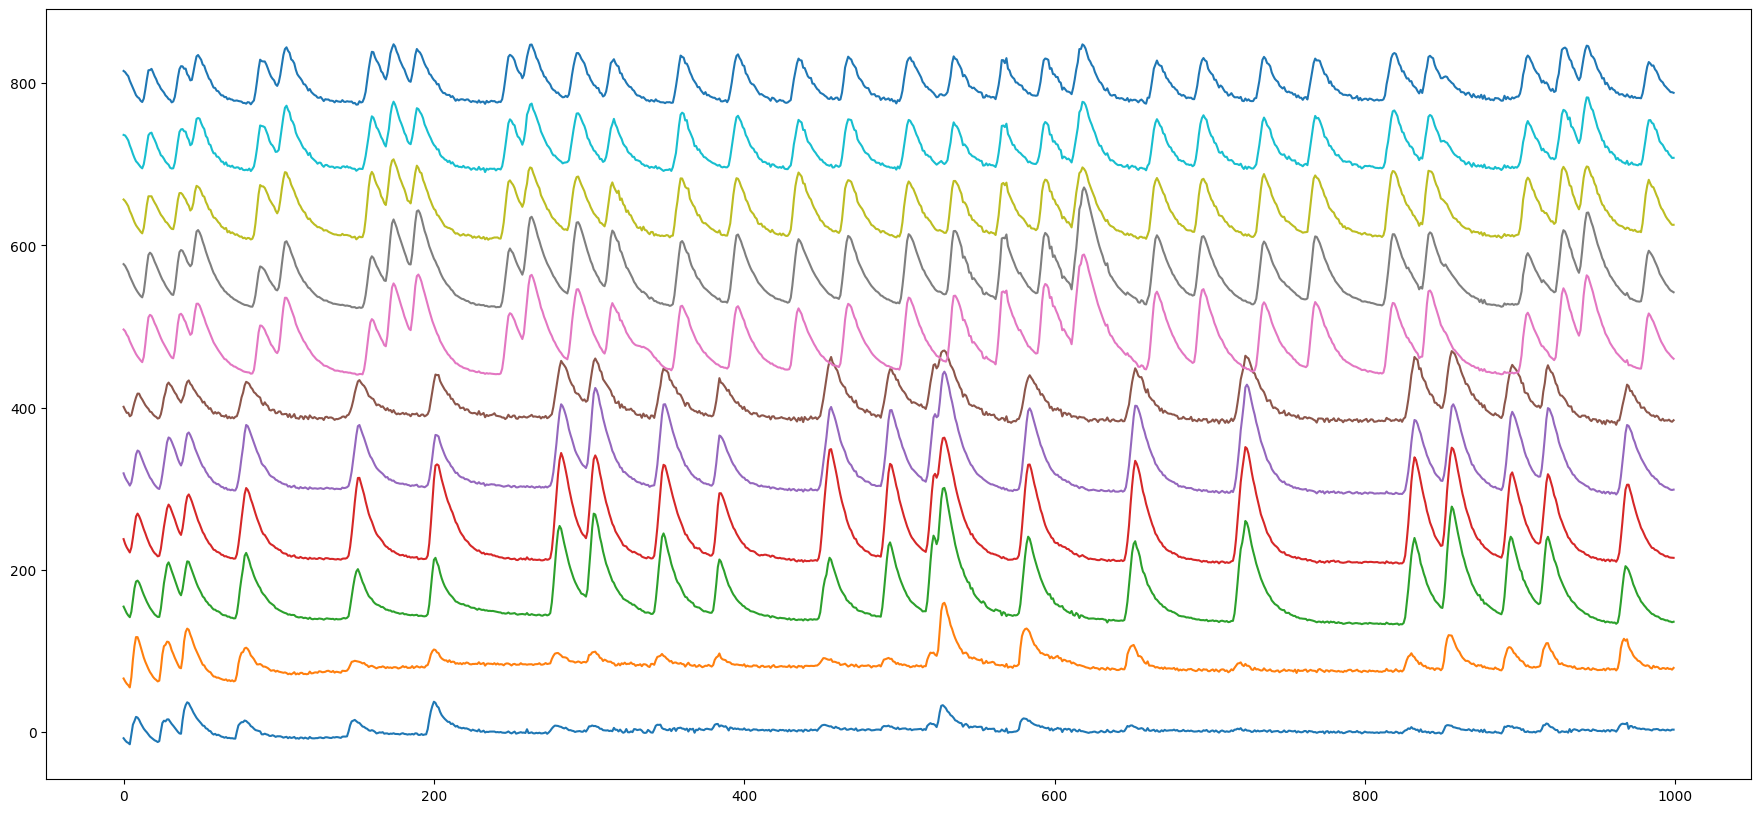

In [5]:
X_new = replace_nan(X, np.array([139]), delete_frames=False)
plt.figure(figsize=(22,10))
for i in range(X_new.shape[0]):
    plt.plot(X_new[i]+ i*80)

In [6]:
f_c, f_s, M = 1.75, 4, 21
gc_rise = GcStar(n_perm = 1000, n_pasts = 4, n_lags = 2, temporal = True)

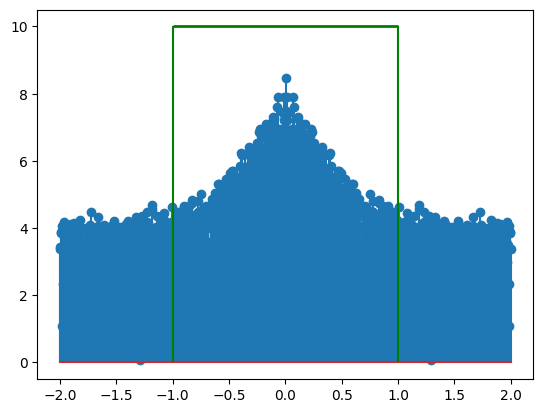

In [7]:
# using a low-pass filter
plt.stem(np.fft.fftshift(np.linspace(-f_s/2,f_s/2,X.shape[1])),np.log(np.abs(np.fft.fft(X[1]))))
plt.vlines([-1, 1],0,10,color='green')
plt.hlines(10,-1,1,lw=2,color='green')

In [8]:
def ideal_lp(f_c,f_s,M):
    amp = np.ones(M)
    amp[int(f_c*M/f_s):-int(f_c*M/f_s)] = 0
    phase = np.zeros(M)
    H_f = amp*np.exp(1j*phase)
    h_n = np.fft.fftshift(np.real(np.fft.ifft(H_f)))
    return h_n


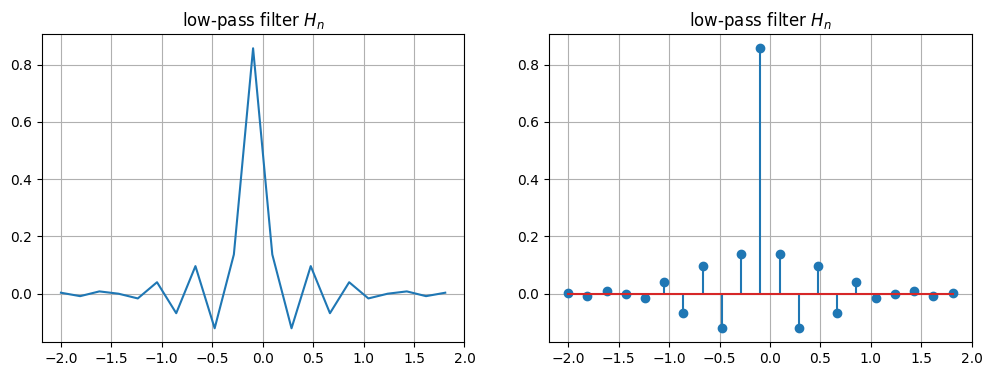

In [9]:
h_n = ideal_lp(f_c, f_s, M)

# plotting amplitude and phase
fig,ax = plt.subplots(1,2,figsize=(12,4))
ax[0].plot(np.arange(-len(h_n)/2,len(h_n)/2)*f_s/M, h_n)
ax[0].set_title('low-pass filter $H_{n}$')
ax[0].grid()
ax[1].stem(np.arange(-len(h_n)/2,len(h_n)/2)*f_s/M, h_n)
ax[1].set_title('low-pass filter $H_{n}$')
ax[1].grid()

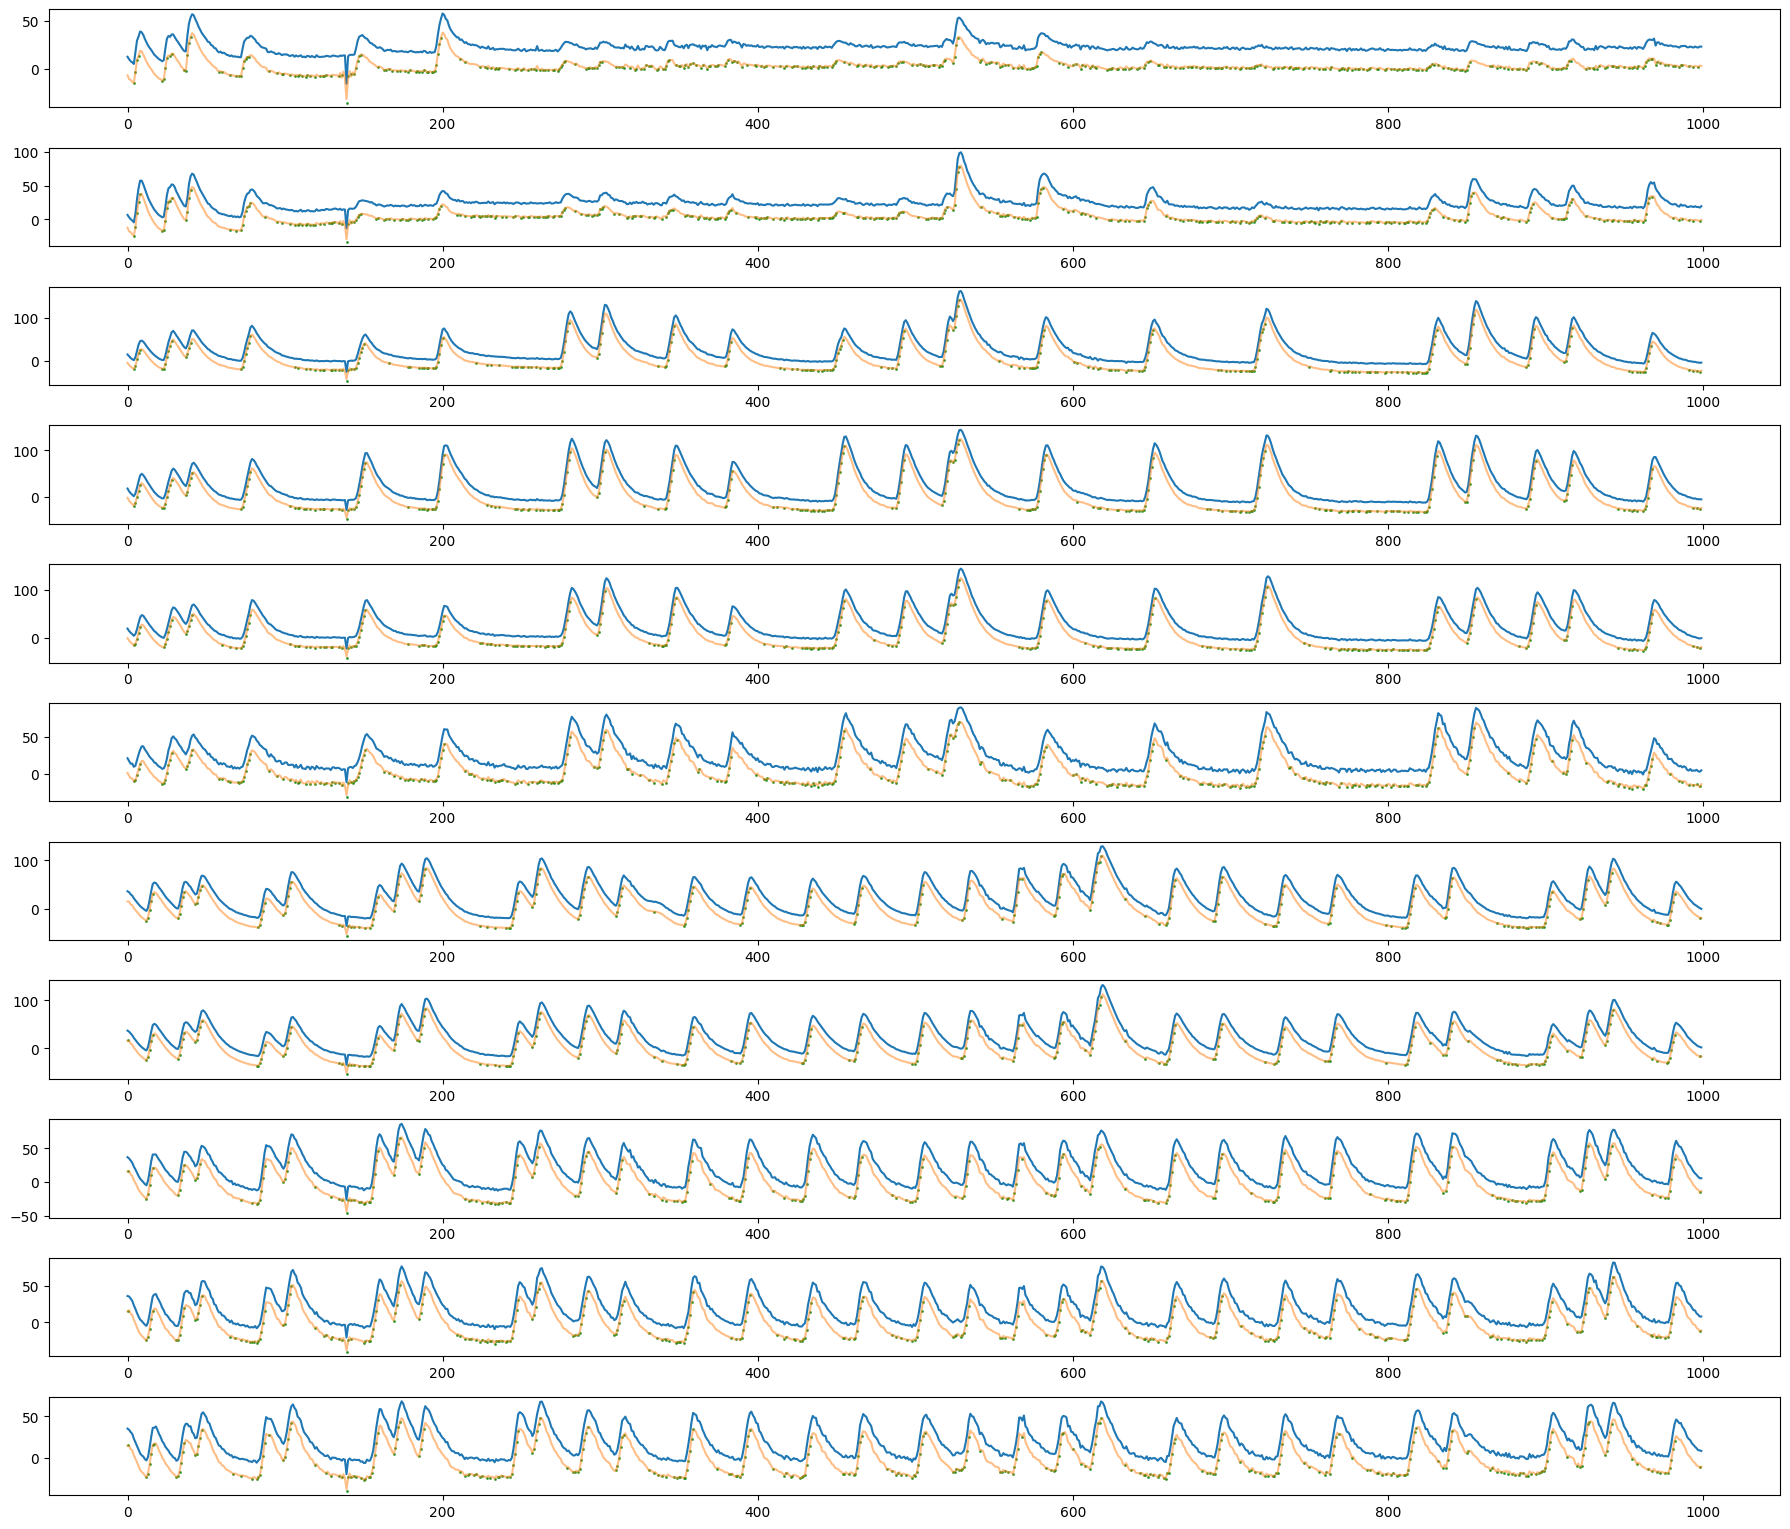

In [10]:
# applying on each row of the data and plotting on X
fig, ax= plt.subplots(X.shape[0], 1, figsize=(18, 1.4 * X.shape[0]))
idx = {}
for i, row in enumerate(X):
    new, idx[i] = gc_rise.get_rising_flanks(row, f_c, f_s, M)
    ax[i].plot(row+20,label=f'raw_{i}')
    ax[i].plot(np.convolve(row,h_n,'same'),alpha=0.5,label=f'filtered_{i}')
    ax[i].scatter(idx[i],new,marker='.',s=5,color='green',alpha=0.65,label='rising flanks')
plt.tight_layout()

In [11]:
idx

{0: array([  4,   5,   6,   7,  22,  23,  24,  25,  27,  28,  36,  37,  38,
         39,  40,  58,  60,  65,  69,  71,  72,  73,  74,  75,  76,  77,
         90,  95,  98,  99, 103, 106, 108, 109, 111, 113, 114, 116, 119,
        122, 124, 125, 126, 129, 134, 136, 139, 140, 142, 144, 145, 146,
        147, 148, 159, 163, 164, 166, 168, 171, 173, 176, 178, 179, 183,
        184, 185, 187, 188, 190, 191, 193, 194, 195, 196, 197, 198, 199,
        211, 214, 224, 227, 228, 231, 233, 234, 235, 236, 242, 246, 247,
        250, 251, 254, 256, 258, 259, 262, 264, 265, 267, 270, 271, 273,
        274, 275, 276, 277, 278, 284, 291, 292, 293, 295, 296, 298, 299,
        300, 301, 310, 312, 314, 315, 319, 322, 323, 326, 328, 329, 331,
        332, 336, 337, 340, 341, 342, 343, 344, 348, 350, 351, 353, 354,
        356, 357, 359, 361, 364, 365, 368, 369, 370, 373, 374, 375, 379,
        380, 381, 384, 385, 387, 390, 393, 398, 399, 402, 404, 405, 410,
        414, 417, 418, 422, 423, 425, 428, 430, 

### Causal Analysis on rising flanks

We instantiate the class with global variables such as the
   * number of permutation = 1000,
   * number of pasts states = 5,
   * number of lags = 3


In [12]:
%%time
gc_rise.fit_rising(X, idx= idx)

  0%|          | 0/44 [00:00<?, ?it/s]

CPU times: total: 1min 54s
Wall time: 1min 55s


Get connectivity matrix and plot both the extended inferred matrix

Text(0.5, 1.0, '33 connections')

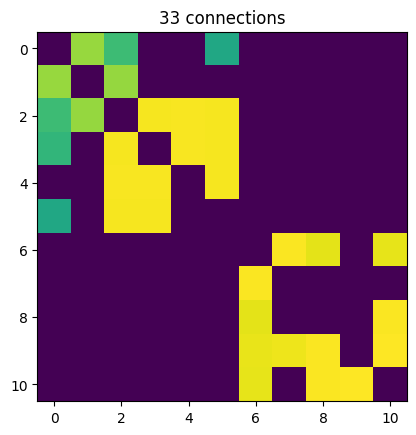

In [13]:
inferred = gc_rise.get_connectivity_matrix()
plt.imshow(inferred)
plt.title(f'{np.sum(inferred != 0)} connections')

C:\Users\sadiq\Documents\GC-extension\src\d_CSL.py:527: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axs[a].imshow(jj)


TypeError: Image data of dtype object cannot be converted to float

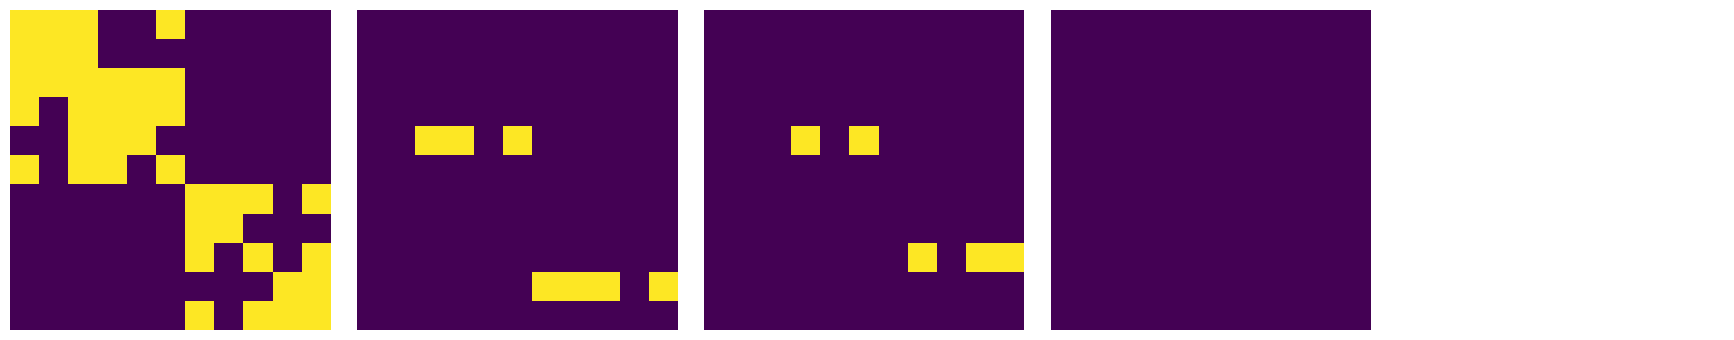

In [14]:
plt.imshow(gc_rise.plot_extended_connectivity_matrix())